### Spherical pendulum: solution by Jacobi function

The total mechanical energy of a spherical pendulum with fixed length $l$, mass $m$, and no friction, using spherical coordinates $(\theta, \phi)$ where $\theta$ is the polar angle from the vertical and $\phi$ the azimuthal angle, and taking the ground (lowest point, $\theta = 0$) as zero potential, is:

$$
    E = \frac{1}{2} m l ^ 2 \left( \dot{\theta} ^ 2 + \sin ^ 2 \theta \, \dot{\phi} ^ 2 \right) + m g l \, (1 - \cos\theta)
$$

This quantity is conserved over time. Another quantity conserved is the angular momentum $L_Z$:

$$
    L_z = m l ^ 2 \, \dot{\phi} \sin ^ 2{\theta}
$$

Substituting it into the energy equation, we obtain a differential equation in $\theta(t)$:

$$
    \dot{\theta} ^ 2 = \frac{2E}{m l^2} - \frac{L_z^2}{m^2 l^4 \sin^2\theta} - \frac{2g}{l} (1 - \cos\theta)
$$

To simplify it, let $u = \cos{\theta}$, with $u \in [-1, 1]$. Substituting, we get a differential equation in $u(t)$:

$$
    \dot{u} ^ 2 = (1-u^2)\left( \frac{2E}{ml^2} - \frac{2g}{l} + \frac{2g}{l}\,u \right) - \frac{L_z^2}{m^2 l^4}
$$

Let's make it dimensionless. Introduce:

- $ \tau = t \sqrt{\frac{g}{l}} $ (dimensionless time)
- $ E' = \frac{E}{m g l} $ (dimensionless total energy)
- $ L_z' = \frac{L_z}{m l^2 \sqrt{g/l}} = \frac{L_z}{m l^{3/2} \sqrt{g}} $ (dimensionless angular momentum)

The differential equation becomes:

$$
    \dot{u}^2 = 2(1-u^2)(u + E' - 1) - L_z'^{\,2}
$$

Taking the square root (the sign depends on the direction of motion), we have:

$$
    \frac{du}{d\tau} = \pm \sqrt{ 2(1-u^2)(u + E' - 1) - L_z'^{\,2} }
$$

Separating the variables, we write:

$$
    d\tau = \pm \frac{du}{\sqrt{ 2(1-u^2)(u + E' - 1) - L_z'^{\,2} }}
$$

Integrating both sides yields the implicit solution (assume $\tau_0 = 0$ for simplicity):

$$
    \tau = \pm \int_{u_0}^{u} \frac{du'}{\sqrt{ 2(1-u'^2)(u' + E' - 1) - L_z'^{\,2} }}
$$

The solution $u(\tau)$ is given by:

$$
    \boxed{u(\tau) = u_2 + (u_3 - u_2) \operatorname{cn}^2\!\left( \omega_1 \, (\tau - \tau_{shift}) ,\, k \right)}
$$

Where $u_1$, $u_2$ and $u_3$ are the real roots of the cubic polynomial in $u$, with $u_1 < u_2 < u_3$. Physics happens between $u_2$ and $u_3$ where the polynomial is positive.
Modulus $k = \sqrt{\frac{u_3 - u_2}{u_3 - u_1}}$.
'cn' is the Jacobi cosine function.
$\tau_{shift}$ is equal to $\frac{1}{\omega_1} \, cn^{-1} \left(\omega_2, k \right)$, where $\omega_1 = \sqrt{\frac{u_3 - u_1}{2}}$ and $\omega_2 = \sqrt{\frac{u_0 - u_2}{u_3 - u_2}}$.

The initial conditions can be written as:

\begin{aligned}
    u_0 &= \cos{\theta_0} \\
    \frac{du}{d\tau}(0) &= - \dot{\theta}_0 \, \sqrt{\frac{l}{g}} \, \sin{\theta_0} \\
    \frac{d\phi}{d\tau}(0) &= \dot{\phi}_0 \, \sqrt{\frac{l}{g}}
\end{aligned}

Because $E$ and $L_z$ are conserved, we can evaluate $E'$ and $L_z'$ at the initial time $\tau_0$ directly from the initial angles and velocities:

\begin{aligned}
    E' &= \frac{1}{2}\left(\frac{\dot{u_0}^{\,2}}{1-u_0^2} + \dot{\phi_0}^{\,2}(1-u_0^2)\right) + 1 - u_0 \\
    L_z' &= \dot{\phi_0}\,(1-u_0^2)
\end{aligned}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq # Root finding algorithm
from scipy.integrate import cumulative_trapezoid # For phi(tau)
from scipy.special import (ellipj, # For 'cn' function
                           ellipkinc) # Incomplete elliptic integral of the first kind

In [2]:
l = 2
g = 9.81

# Initial values for theta and phi
theta0 = np.pi / 3.0
theta0_vel_t = - 0.15
phi0 = 0.3
phi0_vel_t = 0.55

# Initial values of dimensionless variables
u0 = np.cos(theta0)
u0_vel_tau = - theta0_vel_t * np.sqrt(l / g) * np.sin(theta0)
phi0_vel_tau = phi0_vel_t * np.sqrt(l / g)

u0, u0_vel_tau, phi0_vel_tau

(np.float64(0.5000000000000001),
 np.float64(0.058654641525433114),
 np.float64(0.24833800254215202))

In [3]:
# Computing E, L dimensionless
E_prime = 0.5 * (((u0_vel_tau ** 2) / (1 - u0 ** 2)) + ((phi0_vel_tau ** 2) * (1 - u0 ** 2))) + 1 - u0
L_prime = phi0_vel_tau * (1 - u0 ** 2)
E_prime, L_prime

(np.float64(0.525420489296636), np.float64(0.186253501906614))

In [4]:
# Cubic polynomial
def polynomial(u):
    global E_prime, L_prime
    return 2 * (1 - u ** 2) * (u + E_prime - 1) - L_prime ** 2

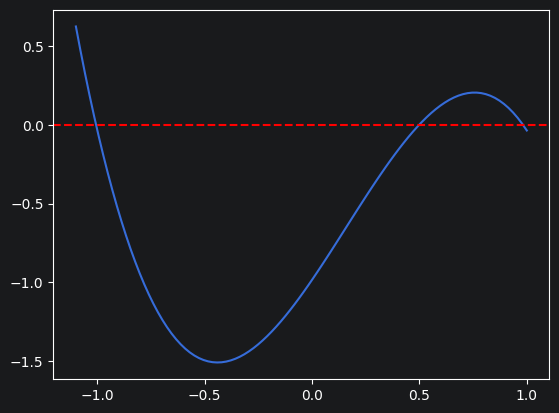

In [5]:
# Visualize P(u) to find real roots
u = np.linspace(- 1.1, 1, 100)
plt.plot(u, polynomial(u))
plt.axhline(y = 0.0, linestyle = '--', color = 'r')
plt.show()

In [6]:
# Computing u1, u2, u3
u1, u2, u3 = brentq(polynomial, - 1.1, - 0.9), brentq(polynomial, 0.4, 0.6), brentq(polynomial, 0.9, 1.1)
u1, u2, u3

(-1.0058411348420109, 0.4976338610532027, 0.9827867844921706)

In [7]:
# dimensionless time
t_max = 5.0
tau_max = t_max * np.sqrt(g / l)
tau = np.linspace(0.0, tau_max, 150)
tau

array([ 0.        ,  0.07431958,  0.14863916,  0.22295874,  0.29727832,
        0.3715979 ,  0.44591747,  0.52023705,  0.59455663,  0.66887621,
        0.74319579,  0.81751537,  0.89183495,  0.96615453,  1.04047411,
        1.11479369,  1.18911327,  1.26343285,  1.33775242,  1.412072  ,
        1.48639158,  1.56071116,  1.63503074,  1.70935032,  1.7836699 ,
        1.85798948,  1.93230906,  2.00662864,  2.08094822,  2.1552678 ,
        2.22958737,  2.30390695,  2.37822653,  2.45254611,  2.52686569,
        2.60118527,  2.67550485,  2.74982443,  2.82414401,  2.89846359,
        2.97278317,  3.04710275,  3.12142232,  3.1957419 ,  3.27006148,
        3.34438106,  3.41870064,  3.49302022,  3.5673398 ,  3.64165938,
        3.71597896,  3.79029854,  3.86461812,  3.9389377 ,  4.01325727,
        4.08757685,  4.16189643,  4.23621601,  4.31053559,  4.38485517,
        4.45917475,  4.53349433,  4.60781391,  4.68213349,  4.75645307,
        4.83077265,  4.90509222,  4.9794118 ,  5.05373138,  5.12

In [8]:
# Computing k, the modulus
k = np.sqrt((u3 - u2) / (u3 - u1))
k

np.float64(0.4939267646794449)

In [9]:
# Computing omega1 and omega2
omega1 = np.sqrt((u3 - u1) / 2.0)
omega2 = np.sqrt((u0 - u2) / (u3 - u2))
omega1, omega2

(np.float64(0.9971529269209867), np.float64(0.06983623146166029))

In [10]:
# Computing tau_shift
tau_shift = (ellipkinc(np.arccos(omega2), k ** 2) / omega1) * np.sign(u0_vel_tau)
tau_shift

np.float64(1.606707522000847)

In [11]:
# Computing K_array
K_array = omega1 * (tau - tau_shift)
K_array

array([-1.60213311, -1.52802512, -1.45391714, -1.37980915, -1.30570116,
       -1.23159318, -1.15748519, -1.08337721, -1.00926922, -0.93516124,
       -0.86105325, -0.78694526, -0.71283728, -0.63872929, -0.56462131,
       -0.49051332, -0.41640533, -0.34229735, -0.26818936, -0.19408138,
       -0.11997339, -0.0458654 ,  0.02824258,  0.10235057,  0.17645855,
        0.25056654,  0.32467452,  0.39878251,  0.4728905 ,  0.54699848,
        0.62110647,  0.69521445,  0.76932244,  0.84343043,  0.91753841,
        0.9916464 ,  1.06575438,  1.13986237,  1.21397036,  1.28807834,
        1.36218633,  1.43629431,  1.5104023 ,  1.58451028,  1.65861827,
        1.73272626,  1.80683424,  1.88094223,  1.95505021,  2.0291582 ,
        2.10326619,  2.17737417,  2.25148216,  2.32559014,  2.39969813,
        2.47380612,  2.5479141 ,  2.62202209,  2.69613007,  2.77023806,
        2.84434605,  2.91845403,  2.99256202,  3.06667   ,  3.14077799,
        3.21488597,  3.28899396,  3.36310195,  3.43720993,  3.51

In [12]:
# Computing cn ^ 2
integral = ellipj(K_array, k ** 2)[1] ** 2
integral

array([4.87709922e-03, 1.79659685e-02, 3.91462460e-02, 6.81695105e-02,
       1.04683696e-01, 1.48226729e-01, 1.98219717e-01, 2.53960639e-01,
       3.14619664e-01, 3.79237346e-01, 4.46726989e-01, 5.15882440e-01,
       5.85392392e-01, 6.53861957e-01, 7.19841831e-01, 7.81864738e-01,
       8.38488179e-01, 8.88341759e-01, 9.30176689e-01, 9.62914531e-01,
       9.85691943e-01, 9.97898199e-01, 9.99202620e-01, 9.89569730e-01,
       9.69260889e-01, 9.38822282e-01, 8.99060247e-01, 8.51005909e-01,
       7.95871870e-01, 7.35004116e-01, 6.69832415e-01, 6.01822229e-01,
       5.32430698e-01, 4.63068572e-01, 3.95069274e-01, 3.29665521e-01,
       2.67973347e-01, 2.10982857e-01, 1.59554674e-01, 1.14420876e-01,
       7.61891044e-02, 4.53485960e-02, 2.22769693e-02, 7.24676944e-03,
       4.30966549e-04, 1.90680687e-03, 1.16576272e-02, 2.95724583e-02,
       5.54434553e-02, 8.89614053e-02, 1.29709777e-01, 1.77157986e-01,
       2.30654756e-01, 2.89422629e-01, 3.52554837e-01, 4.19015815e-01,
      

In [13]:
# Solution u(tau)
u = u2 + (u3 - u2) * integral
u

array([0.5       , 0.5063501 , 0.51662578, 0.5307065 , 0.54842146,
       0.56954649, 0.59380074, 0.62084361, 0.65027251, 0.68162197,
       0.71436477, 0.74791573, 0.78163869, 0.8148569 , 0.84686723,
       0.87695782, 0.90442885, 0.92861546, 0.9489118 , 0.96479466,
       0.97584519, 0.98176709, 0.98239993, 0.97772651, 0.96787361,
       0.95310624, 0.93381557, 0.91050187, 0.88375343, 0.85422326,
       0.82260502, 0.78960967, 0.75594417, 0.72229293, 0.68930287,
       0.65757205, 0.62764191, 0.59999281, 0.57504228, 0.55314548,
       0.53459723, 0.51963486, 0.5084416 , 0.50114965, 0.49784295,
       0.49855895, 0.50328959, 0.51198103, 0.52453242, 0.54079375,
       0.56056294, 0.58358258, 0.60953669, 0.6380481 , 0.66867687,
       0.70092061, 0.73421705, 0.76794971, 0.80145683, 0.83404407,
       0.86500077, 0.89361957, 0.9192185 , 0.94116482, 0.95889897,
       0.97195723, 0.97999156, 0.98278506, 0.9802618 , 0.97249038,
       0.95968071, 0.94217447, 0.92042992, 0.8950023 , 0.86652

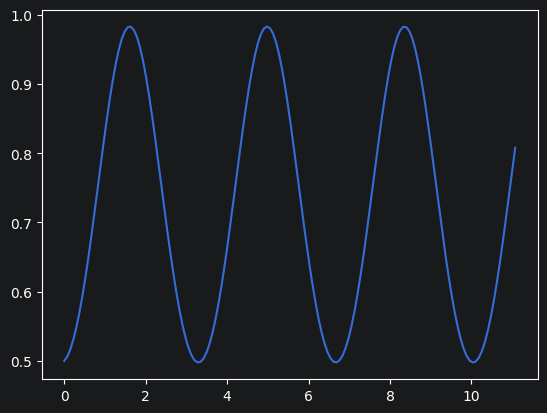

In [14]:
plt.plot(tau, u)
plt.show()

In [15]:
# Check u(0) = u0?
u[0], u0

(np.float64(0.5000000000000001), np.float64(0.5000000000000001))

In [16]:
# Check du/dtau(0) = u0_vel_tau?
np.gradient(u, tau)[0], u0_vel_tau

(np.float64(0.08544320693909666), np.float64(0.058654641525433114))

In [17]:
# Computing theta(tau)
theta = np.arccos(u)
theta

array([1.04719755, 1.03984943, 1.02789096, 1.01136241, 0.99032101,
       0.96484232, 0.93502199, 0.90097796, 0.86285324, 0.82081928,
       0.77508041, 0.72587976, 0.67350758, 0.61831404, 0.56072979,
       0.50130155, 0.44075727, 0.38013255, 0.32102718, 0.26613482,
       0.22023935, 0.1912516 , 0.18789325, 0.21145529, 0.25416487,
       0.30745706, 0.36586244, 0.42630019, 0.48697294, 0.54674133,
       0.60481903, 0.6606237 , 0.71370112, 0.76368426, 0.81026997,
       0.85320481, 0.89227583, 0.9273042 , 0.9581405 , 0.98466109,
       1.00676524, 1.0243728 , 1.03742229, 1.04586954, 1.04968652,
       1.04886073, 1.04339487, 1.03330691, 1.01863051, 0.99941586,
       0.9757309 , 0.94766285, 0.9153203 , 0.87883568, 0.83836843,
       0.7941089 , 0.7462836 , 0.69516237, 0.64106912, 0.58439853,
       0.52564441, 0.46545027, 0.40470524, 0.34473564, 0.28770021,
       0.23738083, 0.20037726, 0.18582015, 0.19901494, 0.23510288,
       0.28493222, 0.34173554, 0.40161745, 0.46235998, 0.52260

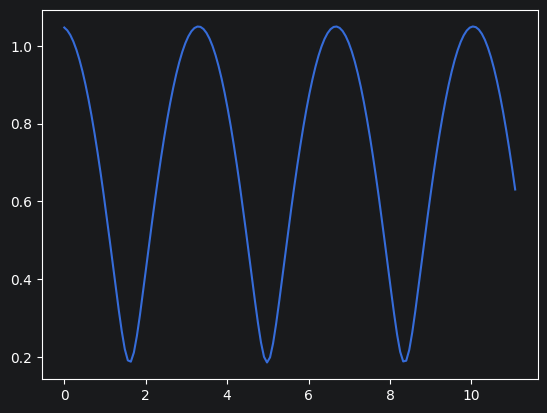

In [18]:
plt.plot(tau, theta)
plt.show()

In [19]:
# Check theta(0) = theta_0?
theta[0], theta0

(np.float64(1.0471975511965976), 1.0471975511965976)

In [20]:
# Check dtheta_dt = theta0_vel_t?
np.gradient(theta, tau)[0] / np.sqrt(l / g), theta0_vel_t

(np.float64(-0.21897399381115437), -0.15)

In [21]:
# Integrate L_prime to retrieve phi(tau)
integrand = L_prime / (1 - u ** 2)
phi = phi0 + cumulative_trapezoid(integrand, tau, initial = 0)
phi

array([ 0.3       ,  0.31853568,  0.33728413,  0.35635984,  0.37589279,
        0.39603515,  0.41696999,  0.43892272,  0.46217681,  0.48709608,
        0.51415725,  0.54399883,  0.57749675,  0.61588514,  0.66095552,
        0.71539656,  0.78339183,  0.87169051,  0.99147553,  1.16104639,
        1.40612217,  1.74268414,  2.1325966 ,  2.48808182,  2.75467474,
        2.93971846,  3.06936253,  3.16391655,  3.23600057,  3.29321201,
        3.34022358,  3.38001202,  3.41454425,  3.44516496,  3.47282207,
        3.49820239,  3.52181589,  3.54404981,  3.56520441,  3.58551726,
        3.60518034,  3.6243523 ,  3.64316771,  3.66174422,  3.68018837,
        3.69860067,  3.71708016,  3.73572896,  3.75465695,  3.77398707,
        3.79386154,  3.81444968,  3.83595807,  3.85864432,  3.88283633,
        3.90896014,  3.93758117,  3.96946733,  4.00568854,  4.04777854,
        4.09800727,  4.15985444,  4.23885383,  4.34409638,  4.49066043,
        4.70178189,  5.00164336,  5.37911326,  5.75895094,  6.06

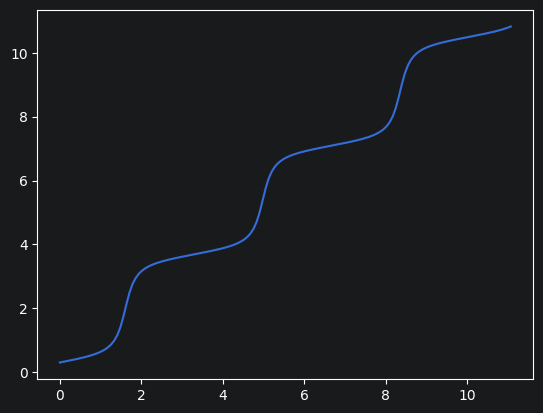

In [22]:
plt.plot(tau, phi)
plt.show()

In [23]:
# Check phi(0) = phi_0?
phi[0], phi0

(np.float64(0.3), 0.3)

In [24]:
# Check dphi_dt(0) = phi_vel_tau
np.gradient(phi, tau)[0], phi0_vel_tau

(np.float64(0.24940508527769772), np.float64(0.24833800254215202))